In [1]:
from datasets import load_dataset
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt


/Users/Kitu/anaconda3/envs/d266myassignment/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:


ds = load_dataset("deelow/restaurant-reviews")

Generating train split: 100%|██████████| 13/13 [00:00<00:00, 1038.41 examples/s]


In [3]:
ds.column_names

{'train': ['name', 'review', 'average_review', 'menu', 'stars']}

Class distribution:
 rating_bucket
2      1
3      1
4      4
4.5    1
5      6
Name: count, dtype: int64


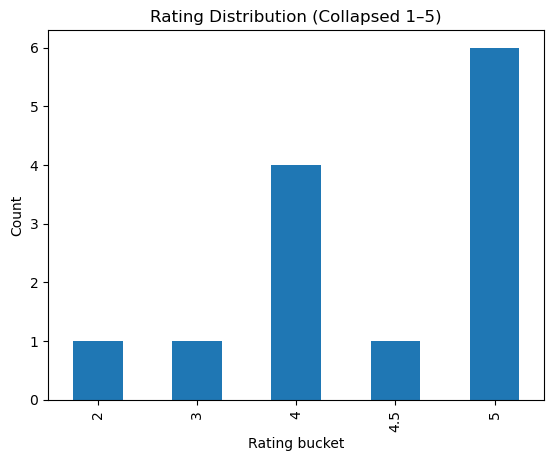

In [6]:

#ds = load_dataset("Mouwiya/drug-reviews")

# Convert to Pandas for exploration (train split only as example)
df = ds["train"].to_pandas()


df["rating_bucket"] = df["stars"]

# Check distribution (imbalance)
rating_counts = df["rating_bucket"].value_counts().sort_index()
print("Class distribution:\n", rating_counts)

# visualize the distribution
rating_counts.plot(kind="bar", title="Rating Distribution (Collapsed 1–5)")
plt.xlabel("Rating bucket")
plt.ylabel("Count")
plt.show()



In [ ]:
# Balance dataset (undersample the majority class for demonstration)
min_count = rating_counts.min()
balanced_df = df.groupby("rating_bucket", group_keys=False).apply(
    lambda x: x.sample(min_count, random_state=42)
)

print("\nBalanced class distribution:\n", balanced_df["rating_bucket"].value_counts())

In [12]:
balanced_df.head(10)


,patient_id,drugName,condition,review,rating,date,usefulCount,review_length,rating_bucket
25659,181982,Teriflunomide,multiple sclerosis,"""I've had MS since I was fifteen, I'm fifty-fo...",1.0,"October 3, 2017",4,100,1
14313,209748,Lupron Depot,endometriosis,"""I am on my 2nd shot of Lupron and I am not li...",2.0,"March 26, 2009",43,79,1
2008,161441,Diphenhydramine,insomnia,"""I tried using it, took two pills (Recommended...",1.0,"June 10, 2016",8,31,1
5865,83784,Ethinyl estradiol / norgestimate,birth control,"""I have been on Sprintec for 4 months now, wit...",1.0,"November 28, 2017",0,128,1
8688,71716,Tramadol,back pain,"""Tramadol is just about as useful as Teats on ...",1.0,"February 27, 2017",24,64,1
27526,81572,Liraglutide,weight loss,"""Been taking Saxenda since 19th May - and so f...",2.0,"July 30, 2017",8,94,1
6743,29134,Topiramate,migraine prevention,"""I started to take topiramate 100mg 6wks ago a...",2.0,"March 12, 2017",10,109,1
17227,152475,Ciprofloxacin,bladder infection,"""I had to stop taken the medicine due to getti...",2.0,"March 5, 2011",70,72,1
5472,177240,Duloxetine,major depressive disorde,"""I started this drug back in the summer-ish of...",2.0,"April 13, 2017",11,95,1
13349,127148,Metoclopramide,nausea/vomiting,"""I was given the medication in tablet form whe...",1.0,"April 20, 2016",8,71,1


In [13]:
# save the balanced dataset to you current directory
balanced_df.to_csv("DrugReview_balanced.csv")

Class distribution:
 rating_bucket
1    2043
2    2043
3    2043
4    2043
5    2043
Name: count, dtype: int64


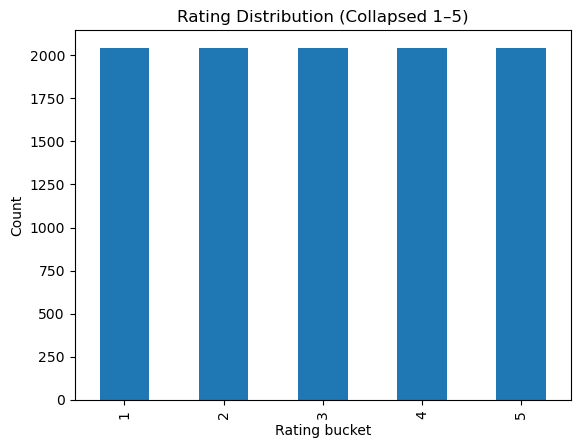

In [14]:
#Revalidate the balanced distribution
# Check distribution (imbalance)
rating_counts = balanced_df["rating_bucket"].value_counts().sort_index()
print("Class distribution:\n", rating_counts)

# visualize
rating_counts.plot(kind="bar", title="Rating Distribution (Collapsed 1–5)")
plt.xlabel("Rating bucket")
plt.ylabel("Count")
plt.show()


In [15]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

text = "This drug really helped with my pain but caused nausea."
candidate_labels = ["very negative", "negative", "neutral", "positive", "very positive"]

result = classifier(text, candidate_labels)
print(result)

ValueError: Your currently installed version of Keras is Keras 3, but this is not yet supported in Transformers. Please install the backwards-compatible tf-keras package with `pip install tf-keras`.